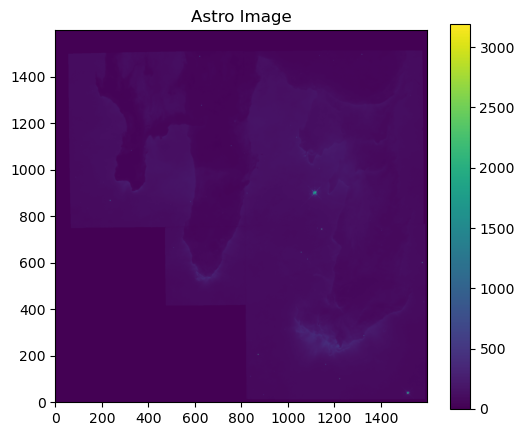

In [1]:
# 3 Review
# 3.1 Plotting an Astronomical Image
import numpy as np
import matplotlib.pyplot as plt

image = np.loadtxt("astro_image.csv")

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(image, origin="lower")
ax.set_title("Astro Image")
cbar = plt.colorbar(im, ax=ax)

plt.show()

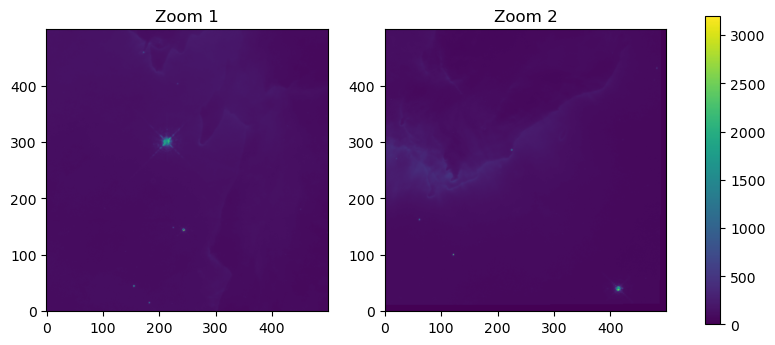

In [2]:
x1a, x2a = 900, 1400
y1a, y2a = 600, 1100
x1b, x2b = 1100, 1600
y1b, y2b = 0, 500

zoom1 = image[y1a:y2a, x1a:x2a]
zoom2 = image[y1b:y2b, x1b:x2b]

vmin, vmax = image.min(), image.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
im1 = ax1.imshow(zoom1, origin="lower", vmin=vmin, vmax=vmax)
ax1.set_title("Zoom 1")
im2 = ax2.imshow(zoom2, origin="lower", vmin=vmin, vmax=vmax)
ax2.set_title("Zoom 2")
cbar = fig.colorbar(im1, ax=[ax1, ax2])
plt.show()

In [3]:
# 3.2 Pandas and Ramen
import pandas as pd
df = pd.read_csv("ramen-ratings.csv")

Column names: Review #, Brand, Variety, Style, Country, Stars, Top Ten

1. What are the column names in this dataset?

In [4]:
print(df.columns)

Index(['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten'], dtype='object')


The ramen style is pack

2. What is the ramen style of the 27th entry?

In [5]:
df.loc[26, "Style"]

'Pack'

There are 355 unique ramen brands

3. How many different ramen brands are there?

In [6]:
df["Brand"].nunique()

355

4. Sort the dataset by brand names.

In [7]:
df_sorted = df.sort_values("Brand")

49 different ramen brands are made in the USA

5. How many ramen brands are made in the USA?

In [8]:
df[df["Country"] == "USA"]["Brand"].nunique()

49

27 different ramen brands in the USA make pack-style ramen

6. How many ramen brands in the USA make pack-style ramen?

In [9]:
df[(df["Country"] == "USA") & (df["Style"] == "Pack")]["Brand"].nunique()

27

'MAMA', 'Prima Taste', 'Prima', 'Tseng Noodles', 'Wugudaochang',
'A-Sha Dry Noodle', 'MyKuali', 'CarJEN', 'Maruchan', 'Mamee', 'Mama', 'Sapporo Ichiban', 'Nongshim', 'Samyang Foods', 'Paldo', 'Indomie', 'Koka', 'Mi Sedaap', 'Nissin', 'Myojo', 'Doll'

7. Challenge: Which ramen brands have been in the top ten? (Top tem column entry is not
NaN)

In [10]:
top_brands = df[df["Top Ten"].notna()]["Brand"].unique()
top_brands

array(['MAMA', 'Prima Taste', 'Prima', 'Tseng Noodles', 'Wugudaochang',
       'A-Sha Dry Noodle', 'MyKuali', 'CarJEN', 'Maruchan', 'Mamee',
       'Mama', 'Sapporo Ichiban', 'Nongshim', 'Samyang Foods', 'Paldo',
       'Indomie', 'Koka', 'Mi Sedaap', 'Nissin', 'Myojo', 'Doll'],
      dtype=object)

In [11]:
# 3.3 Linear Regression
# 3.3.1
from astropy.table import Table

t = Table.read("global_CCl4_MM.dat", format = "ascii")
t.colnames

['CCl4ottoyr',
 'CCl4ottomon',
 'CCl4ottoNHm',
 'CCl4ottoNHsd',
 'CCl4ottoSHm',
 'CCl4ottoSHsd',
 'CCl4ottoGLm',
 'CCl4ottoGLsd']

In [12]:
# 3.3.2
df2 = t.to_pandas()
df2 = df2[['CCl4ottoyr', 'CCl4ottomon', 'CCl4ottoGLm', 'CCl4ottoGLsd']]
df2["date"] = df2["CCl4ottoyr"] + (df2["CCl4ottomon"] - 1) / 12
df2 = df2[["date", "CCl4ottoGLm", "CCl4ottoGLsd"]]
df2 = df2.rename(columns={"CCl4ottoGLm": "global mean concentration", "CCl4ottoGLsd": "global mean concentration sd"})

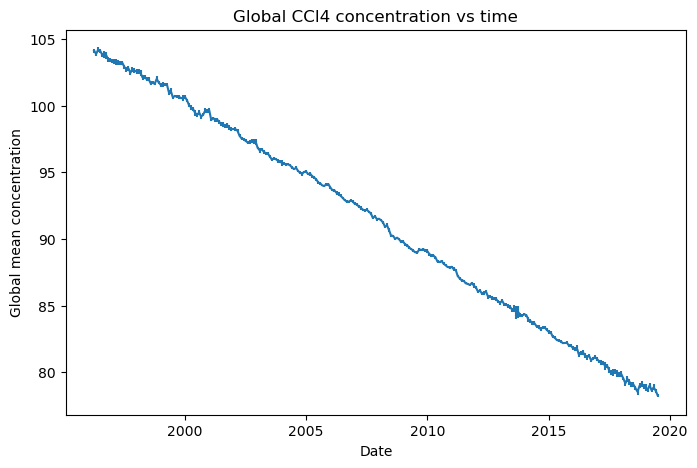

In [13]:
# 3.3.3

plt.figure(figsize=(8,5))
plt.errorbar(df2["date"], df2["global mean concentration"], yerr=df2["global mean concentration sd"])
plt.xlabel("Date")
plt.ylabel("Global mean concentration")
plt.title("Global CCl4 concentration vs time")
plt.show()

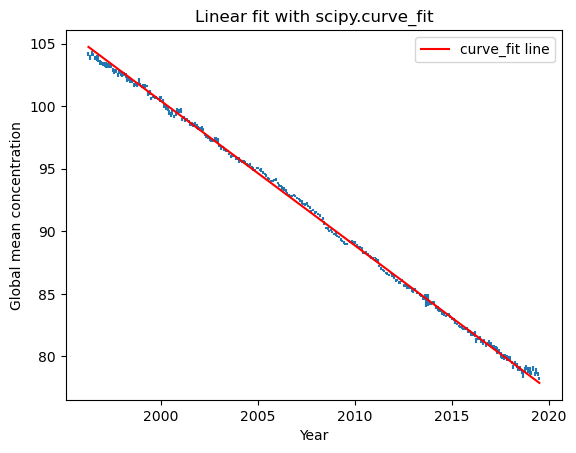

In [14]:
# 3.3.4
from scipy.optimize import curve_fit
def linear_model(x, m, b):
    return m * x + b
x = df2["date"].to_numpy()
y = df2["global mean concentration"].to_numpy()
sigma = df2["global mean concentration sd"].to_numpy()
mask = (~np.isnan(x)) & (~np.isnan(y)) & (~np.isnan(sigma)) & (sigma > 0)
x_fit = x[mask]
y_fit_data = y[mask]
sigma_fit = sigma[mask]

popt, pcov = curve_fit(linear_model, x_fit, y_fit_data, sigma=sigma_fit, absolute_sigma=True)
m, b = popt
m_err, b_err = np.sqrt(np.diag(pcov))

y_model = linear_model(x_fit, m, b)

plt.errorbar(x_fit, y_fit_data, yerr=sigma_fit, linestyle='none')
plt.plot(x_fit, y_model, 'r-', label="curve_fit line")

plt.xlabel("Year")
plt.ylabel("Global mean concentration")
plt.title("Linear fit with scipy.curve_fit")
plt.legend()
plt.show()

y_fit = linear_model(x_fit, m, b)

In [15]:
# 3.3.5
N = len(y_fit_data)
chi2_reduced = (1/(N - 1)) * np.sum(((y_fit - y_fit_data) / sigma_fit)**2)
print(chi2_reduced)

4.420929624596455


In [16]:
# 3.3.6
# My linear fit was relatively accurate, and visually matches the data pretty closely.
# Additionally, the reduced chi-square value is 4.4, which is relatively low, meaning the linear model is accurate.